In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

project_path = "/content/drive/MyDrive/ResumeGPT"

# Load the CLEANED data (from Day 2)
df = pd.read_csv(project_path + "/data/processed/cleaned_resumes.csv")

print("Cleaned data loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Cleaned data loaded!
Shape: (2484, 5)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category', 'cleaned_resume']


In [4]:
# Install wordcloud library — not pre-installed in Colab
!pip install wordcloud

In [5]:
import numpy as np                          # numpy — for numerical operations
import matplotlib.pyplot as plt             # matplotlib — for creating charts/graphs
import seaborn as sns                       # seaborn — for prettier charts
from wordcloud import WordCloud             # for creating word cloud images

from sklearn.feature_extraction.text import TfidfVectorizer
# sklearn = scikit-learn, the most popular ML library in Python
# TfidfVectorizer converts text into TF-IDF numbers

import warnings
warnings.filterwarnings('ignore')           # hide unimportant warning messages

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
df['cleaned_resume'].isnull().sum()

np.int64(1)

In [8]:
print("Missing values in cleaned_resume:", df['cleaned_resume'].isnull().sum())

Missing values in cleaned_resume: 1


In [9]:
df['cleaned_resume'] = df['cleaned_resume'].fillna('')

In [10]:
# Also check for empty strings
empty_count = (df['cleaned_resume'] == '').sum()
print("Empty strings in cleaned_resume:", empty_count)

print("Data is clean and ready for vectorization!")

Empty strings in cleaned_resume: 1
Data is clean and ready for vectorization!


In [11]:
# WHY max_features=5000?
# There could be 50,000+ unique words across all resumes
# We only keep the top 5000 most important ones to keep things manageable

# WHY ngram_range=(1,2)?
# (1,1) = single words only: "machine", "learning"
# (1,2) = single words AND pairs: "machine learning" as one feature
# Pairs capture meaning better — "machine learning" means something specific

# WHY min_df=2?
# Ignore words that appear in fewer than 2 documents
# A word appearing only once is probably a typo or too rare to be useful

print("Starting TF-IDF Vectorization...")
print("This converts all 2484 resumes into numbers...")

vectorizer = TfidfVectorizer(
    max_features=5000,      # keep top 5000 words/phrases
    ngram_range=(1, 2),     # single words + two-word phrases
    min_df=2,               # ignore terms appearing in less than 2 docs
    sublinear_tf=True       # apply log to term frequency (reduces impact of very common words)
)

# fit_transform does two things:
# fit — learns the vocabulary from our data
# transform — converts text to numbers
X = vectorizer.fit_transform(df['cleaned_resume'])

print("Vectorization complete!")
print("Matrix shape:", X.shape)
print(f"This means: {X.shape[0]} resumes × {X.shape[1]} features (words/phrases)")

Starting TF-IDF Vectorization...
This converts all 2484 resumes into numbers...
Vectorization complete!
Matrix shape: (2484, 5000)
This means: 2484 resumes × 5000 features (words/phrases)


In [12]:
# X = the TF-IDF matrix (what we feed into the model)
# y = the category labels (what the model tries to predict)

y = df['Category']

print("Labels (y) prepared!")
print("Unique categories:", y.nunique())
print("Category distribution:")
print(y.value_counts())

Labels (y) prepared!
Unique categories: 24
Category distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


Chart saved!


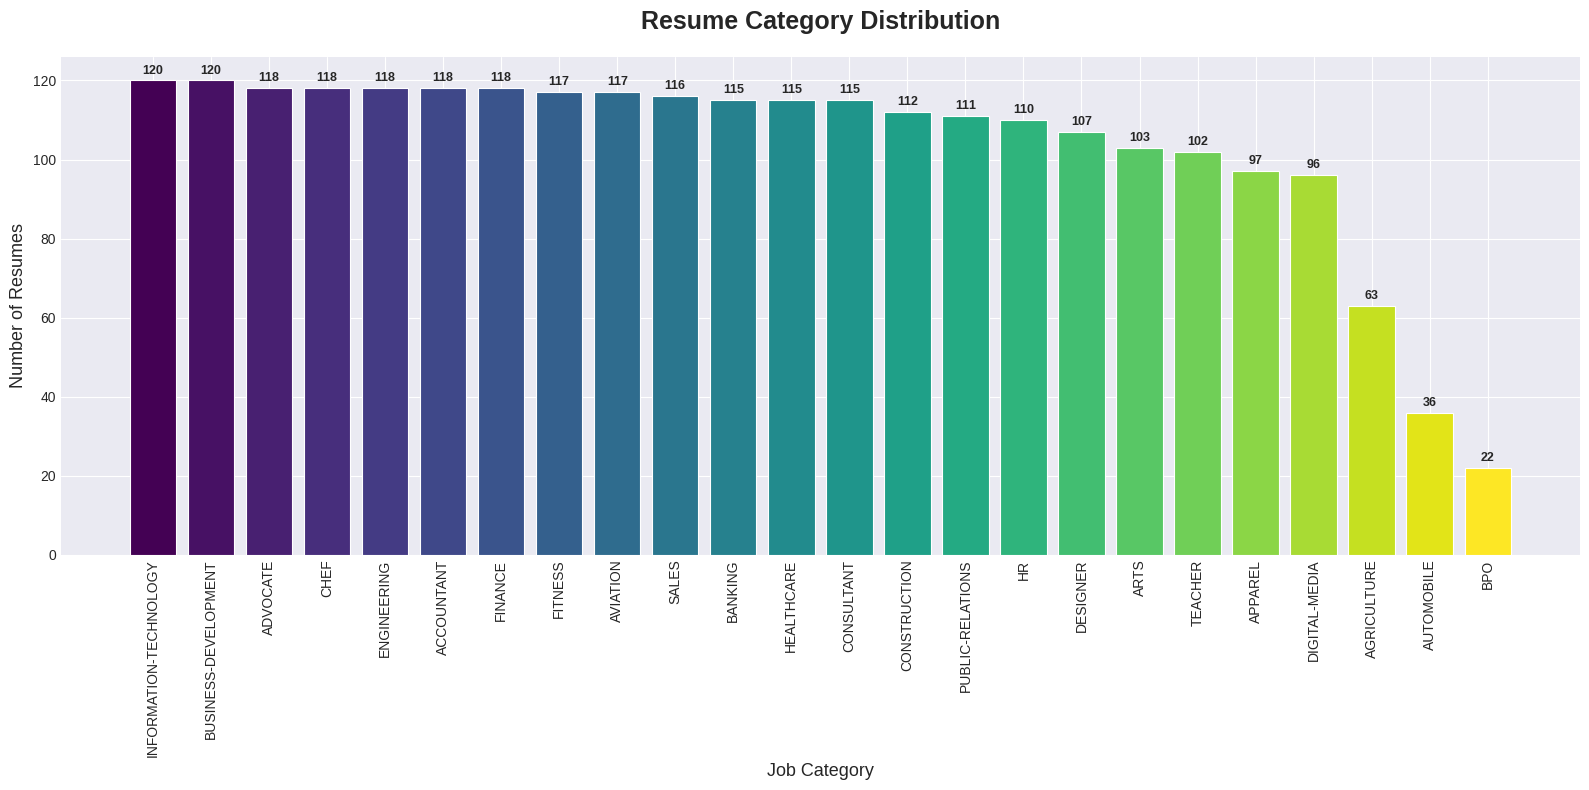

In [14]:
# Set a nice style for all our charts
plt.style.use('seaborn-v0_8-darkgrid')

# Create the figure (think of this as a blank canvas)
fig, ax = plt.subplots(figsize=(16, 8))
# figsize=(width, height) in inches

# Count how many resumes per category and sort them for better readability
category_counts = df['Category'].value_counts().sort_values(ascending=False)

# Create a color gradient — one color per bar
colors = plt.cm.viridis(np.linspace(0, 1, len(category_counts)))

# Draw the bar chart
bars = ax.bar(
    category_counts.index,    # x-axis: category names
    category_counts.values,   # y-axis: counts
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# Add count labels on top of each bar
for bar, count in zip(bars, category_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # x position (center of bar)
        bar.get_height() + 1,                  # y position (just above bar)
        str(count),                            # the text to show
        ha='center',                           # horizontal alignment
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Add titles and labels
ax.set_title('Resume Category Distribution', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Job Category', fontsize=13)
ax.set_ylabel('Number of Resumes', fontsize=13)
ax.tick_params(axis='x', rotation=90)    # rotate x labels to 90 degrees for better readability
plt.tight_layout()                        # auto-adjust spacing

# Save the chart to Google Drive
save_path = project_path + "/assets/result_images/category_distribution.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Total words in all resumes: 1446843
Generating word cloud... (may take 15-20 seconds)
Word cloud saved!


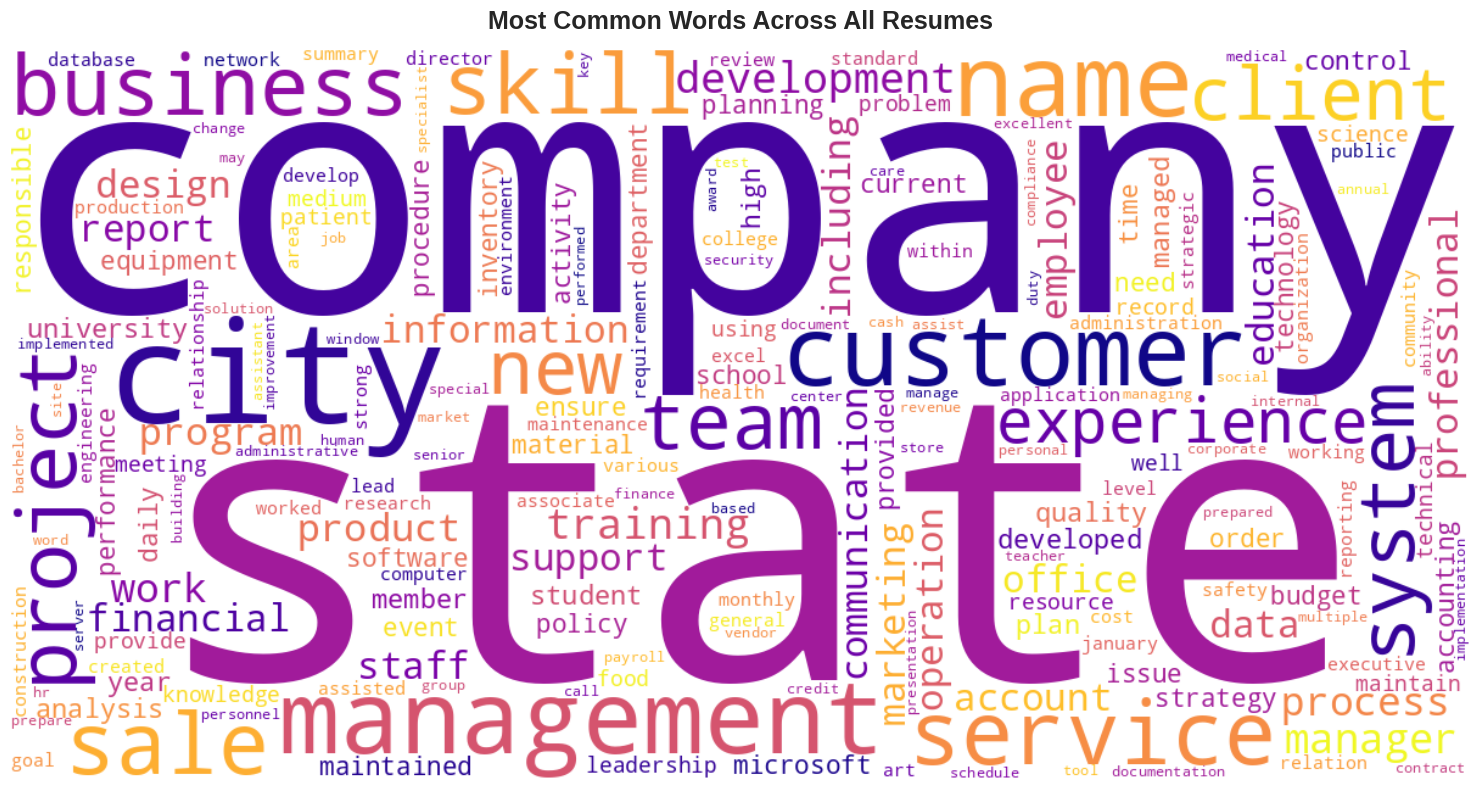

In [15]:
# Combine ALL cleaned resumes into one giant string
all_text = ' '.join(df['cleaned_resume'].tolist())

print("Total words in all resumes:", len(all_text.split()))
print("Generating word cloud... (may take 15-20 seconds)")

# Create the word cloud object
wordcloud = WordCloud(
    width=1200,              # image width in pixels
    height=600,              # image height in pixels
    background_color='white',
    colormap='plasma',       # color scheme (try 'viridis', 'coolwarm', 'plasma')
    max_words=200,           # show top 200 words
    min_font_size=10,
    collocations=False       # don't repeat word pairs already shown as single words
)

# Generate the cloud from our text
wordcloud.generate(all_text)

# Display it
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')              # hide the x and y axes (not needed for images)
ax.set_title('Most Common Words Across All Resumes', fontsize=18, fontweight='bold', pad=15)

plt.tight_layout()

# Save it
save_path = project_path + "/assets/result_images/wordcloud_all.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print("Word cloud saved!")
plt.show()

Category word clouds saved!


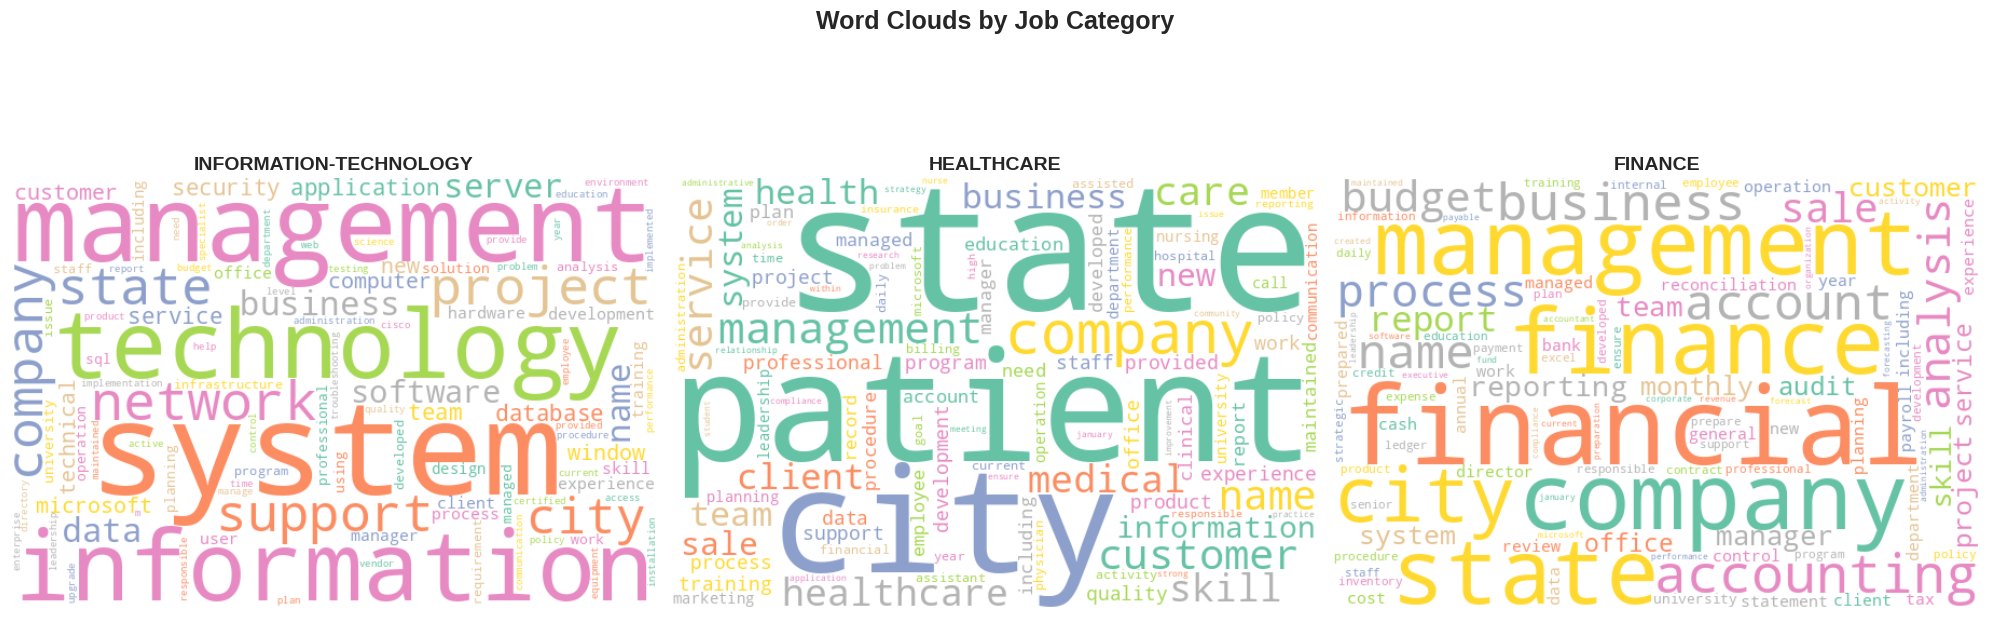

In [16]:
# Pick 3 interesting categories to visualize
selected_categories = ['INFORMATION-TECHNOLOGY', 'HEALTHCARE', 'FINANCE']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
# This creates 3 side-by-side plot areas

for i, category in enumerate(selected_categories):

    # Filter resumes for this category only
    category_text = ' '.join(
        df[df['Category'] == category]['cleaned_resume'].tolist()
    )

    # Generate word cloud for this category
    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='Set2',
        max_words=100,
        collocations=False
    ).generate(category_text)

    # Draw in the i-th subplot
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(category, fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Job Category', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

save_path = project_path + "/assets/result_images/wordcloud_by_category.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print("Category word clouds saved!")
plt.show()

In [17]:
# Get the feature names (all 5000 words/phrases)
feature_names = vectorizer.get_feature_names_out()

# Calculate average TF-IDF score for each feature across all documents
# X.toarray() converts sparse matrix to regular numpy array
avg_tfidf_scores = X.toarray().mean(axis=0)
# axis=0 means: average across rows (across all resumes), keeping columns (features)

# Create a dataframe of features and their scores
tfidf_df = pd.DataFrame({
    'feature': feature_names,
    'avg_score': avg_tfidf_scores
})

# Sort by score descending and take top 25
top_features = tfidf_df.sort_values('avg_score', ascending=False).head(25)

print("Top 25 most important TF-IDF features:")
print(top_features)

Top 25 most important TF-IDF features:
           feature  avg_score
4283         state   0.035760
686           city   0.034619
800        company   0.034175
687     city state   0.034011
2916          name   0.031086
802   company name   0.030889
2918     name city   0.030113
2616    management   0.028752
1065      customer   0.028586
4063       service   0.026214
3906          sale   0.025995
4144         skill   0.024882
531       business   0.024595
708         client   0.023292
4520          team   0.023174
3511       project   0.022947
2962           new   0.022597
4480        system   0.022460
1242   development   0.021669
2656       manager   0.021585
4657      training   0.021382
1637    experience   0.021346
4940          work   0.020807
3446       process   0.020460
3500       program   0.020307


TF-IDF feature chart saved!


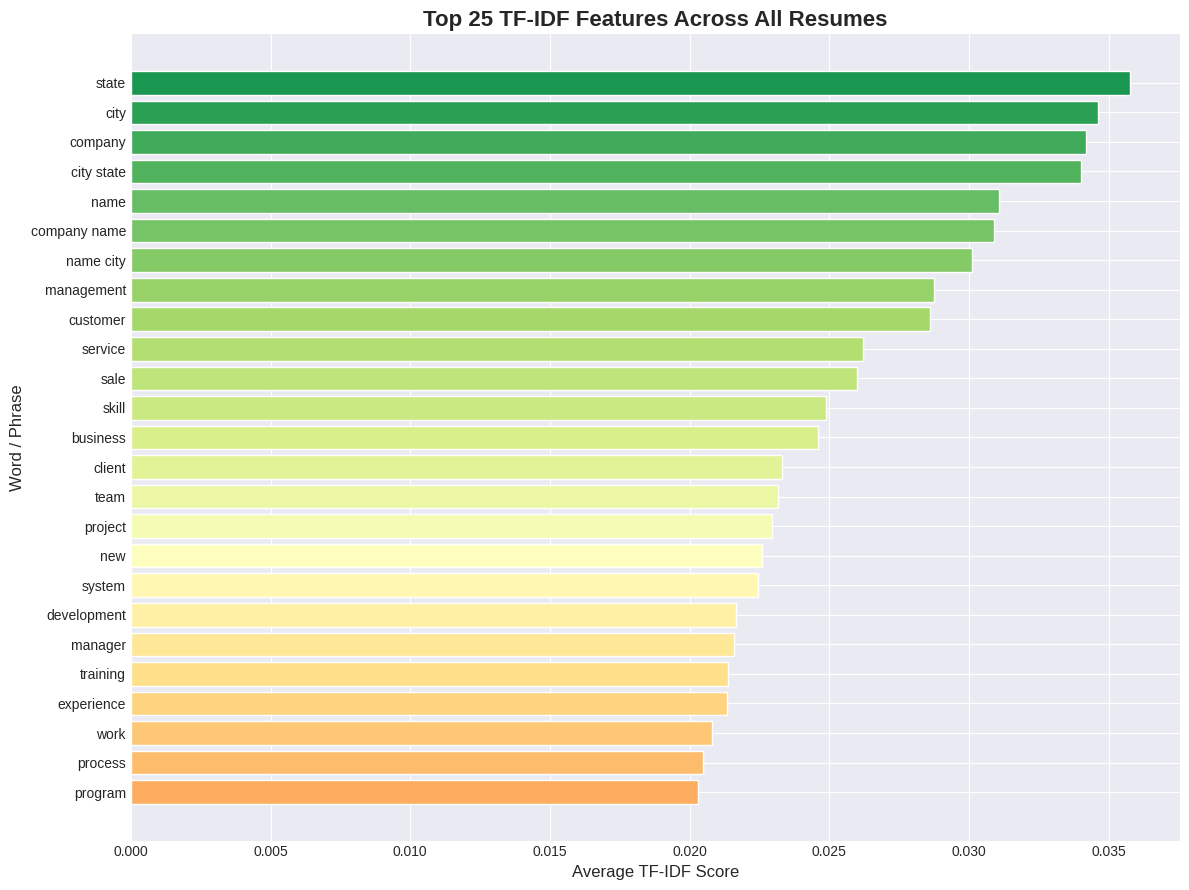

In [18]:
fig, ax = plt.subplots(figsize=(12, 9))

# Horizontal bar chart — easier to read long feature names
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_features)))

ax.barh(
    top_features['feature'],         # y-axis: feature names
    top_features['avg_score'],        # x-axis: scores
    color=colors[::-1],              # reverse colors so highest is greenest
    edgecolor='white'
)

ax.set_title('Top 25 TF-IDF Features Across All Resumes', fontsize=16, fontweight='bold')
ax.set_xlabel('Average TF-IDF Score', fontsize=12)
ax.set_ylabel('Word / Phrase', fontsize=12)
ax.invert_yaxis()                    # highest score at top

plt.tight_layout()

save_path = project_path + "/assets/result_images/top_tfidf_features.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print("TF-IDF feature chart saved!")
plt.show()

In [19]:
import pickle
# pickle = Python's way of saving any object to a file
# Like taking a snapshot of the vectorizer so we can reload it later

vectorizer_path = project_path + "/data/processed/tfidf_vectorizer.pkl"

with open(vectorizer_path, 'wb') as f:
    # 'wb' = write binary (pickle files are binary, not text)
    pickle.dump(vectorizer, f)

print("Vectorizer saved to:", vectorizer_path)

# Also save X (the TF-IDF matrix) as a numpy file
import scipy.sparse
matrix_path = project_path + "/data/processed/tfidf_matrix.npz"
scipy.sparse.save_npz(matrix_path, X)

print("TF-IDF matrix saved to:", matrix_path)
print("\nAll files saved! Day 3 complete.")

Vectorizer saved to: /content/drive/MyDrive/ResumeGPT/data/processed/tfidf_vectorizer.pkl
TF-IDF matrix saved to: /content/drive/MyDrive/ResumeGPT/data/processed/tfidf_matrix.npz

All files saved! Day 3 complete.


In [20]:
# Reload the vectorizer and check it works
with open(vectorizer_path, 'rb') as f:
    # 'rb' = read binary
    loaded_vectorizer = pickle.load(f)

# Test it on a sample resume
test_resume = ["experienced python developer machine learning tensorflow keras"]
test_vector = loaded_vectorizer.transform(test_resume)

print("Vectorizer reload test passed!")
print("Test vector shape:", test_vector.shape)
print("Non-zero features in test:", test_vector.nnz)
# nnz = number of non-zero elements

Vectorizer reload test passed!
Test vector shape: (1, 5000)
Non-zero features in test: 5
